In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import jax.flatten_util
import equinox as eqx
import optax
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from sklearn.linear_model import Ridge
from sklearn.datasets import make_swiss_roll, make_s_curve
from sklearn.preprocessing import StandardScaler
import warnings

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

# Set random seed for numpy (used in sklearn dataset generation)
np.random.seed(42)

In [ ]:
# This config drives the entire experiment pipeline.
config = {
    # Experiment settings
    "seed": 42,
    "dataset_name": "s_curve", # Options: 'linear_functional', 'swiss_roll', 's_curve'
    
    # Dataset parameters
    "num_train": 500,
    "num_val": 500,
    "num_test": 500,
    "k_dim": 2,          # Intrinsic latent dimensionality
    "n_dim": 64,         # Ambient dimensionality (observation space)
    "noise_std": 0.1,    # Noise level for generated data
    
    # Training parameters
    "num_epochs": 1000,
    "batch_size": 32,
    "learning_rate": 1e-4,
    # "weight_decay": 1e-4,
    "weight_decay": 0,
    
    # Model architecture parameters
    "hidden_dim": 128,
    "num_layers": 3,
    
    # JE-VICReg specific parameters
    "vicreg_sim_coeff": 25.0,
    "vicreg_var_coeff": 25.0,
    "vicreg_cov_coeff": 1.0,
    "aug_noise_std": 0.2, # Augmentation noise for contrastive methods
    
    # JEPA specific parameters
    "jepa_ema_decay": 0.996,  # Exponential Moving Average decay for target encoder
    "jepa_mask_ratio": 0.5,   # Percentage of input vector to mask for context/target prediction
}

In [ ]:
def generate_linear_functional(key, N, k, n, sigma):
    """Generates synthetic data based on the linear functional model with Fourier bases."""
    k1, k2 = jrandom.split(key)
    z_star = jrandom.uniform(k1, shape=(N, k), minval=-1.0, maxval=1.0)
    tau = jnp.linspace(1/n, 1.0, n)
    Psi = jnp.column_stack([jnp.cos(2 * jnp.pi * (l + 1) * tau) for l in range(k)])
    x_clean = z_star @ Psi.T
    x_noisy = x_clean + sigma * jrandom.normal(k2, shape=(N, n))
    return x_noisy, z_star

def generate_manifold_data(name, N, n_dim, noise):
    """Generates Scikit-Learn manifold data, projects it to high dimensions, and adds noise."""
    if name == "swiss_roll":
        x_3d, z_1d = make_swiss_roll(n_samples=N, noise=noise)
        # sklearn's make_swiss_roll returns position along the curve. The 2nd orthogonal dimension 
        # is the height along the y-axis, which is found in x_3d[:, 1].
        z_star = np.column_stack((z_1d, x_3d[:, 1])) 
    elif name == "s_curve":
        x_3d, z_1d = make_s_curve(n_samples=N, noise=noise)
        # Similar to swiss_roll, the y-axis is the orthogonal 2nd latent dimension
        z_star = np.column_stack((z_1d, x_3d[:, 1]))
    else:
        raise ValueError(f"Unknown manifold dataset: {name}")
    
    # Normalize latents to roughly [-1, 1]
    z_star = StandardScaler().fit_transform(z_star)
    x_3d = StandardScaler().fit_transform(x_3d)
    
    # Project from 3D ambient to n_dim ambient via a random orthogonal matrix
    Q, _ = np.linalg.qr(np.random.randn(n_dim, 3))
    x_high_dim = x_3d @ Q.T
    
    return jnp.array(x_high_dim), jnp.array(z_star)

def get_dataloaders(config, key):
    """Orchestrates dataset creation and train/val/test splitting."""
    k1, k2, k3 = jrandom.split(key, 3)
    
    if config["dataset_name"] == "linear_functional":
        x_train, z_train = generate_linear_functional(k1, config["num_train"], config["k_dim"], config["n_dim"], config["noise_std"])
        x_val, z_val = generate_linear_functional(k2, config["num_val"], config["k_dim"], config["n_dim"], config["noise_std"])
        x_test, z_test = generate_linear_functional(k3, config["num_test"], config["k_dim"], config["n_dim"], config["noise_std"])
    elif config["dataset_name"] in ["swiss_roll", "s_curve"]:
        # FIX: Generate all data at once so they share the exact same orthogonal projection matrix Q
        total_N = config["num_train"] + config["num_val"] + config["num_test"]
        x_all, z_all = generate_manifold_data(config["dataset_name"], total_N, config["n_dim"], config["noise_std"])
        
        # Slice the generated data into train, val, and test splits
        n_tr = config["num_train"]
        n_v = config["num_val"]
        
        x_train, z_train = x_all[:n_tr], z_all[:n_tr]
        x_val, z_val = x_all[n_tr : n_tr + n_v], z_all[n_tr : n_tr + n_v]
        x_test, z_test = x_all[n_tr + n_v :], z_all[n_tr + n_v :]
    
    return (x_train, z_train), (x_val, z_val), (x_test, z_test)

In [ ]:
def visualize_ambient_data(x, z, dataset_name):
    from sklearn.decomposition import PCA
    
    print(f"Visualizing ambient space for {dataset_name}...")
    pca = PCA(n_components=3)
    x_pca = pca.fit_transform(np.array(x))
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=np.array(z[:, 0]), cmap='viridis', alpha=0.7, s=15)
    
    ax.set_title(f"Ambient Data (PCA Projection) - {dataset_name}\nColored by True Latent Factor 1")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
    fig.colorbar(sc, label="True Latent z_0")
    plt.tight_layout()
    plt.show()

In [ ]:
class AbstractAE(eqx.Module):
    encoder: eqx.nn.MLP
    decoder: eqx.nn.MLP

    def __init__(self, key, n_dim, k_dim, hidden_dim, num_layers):
        k1, k2 = jrandom.split(key)
        self.encoder = eqx.nn.MLP(n_dim, k_dim, hidden_dim, num_layers, key=k1)
        self.decoder = eqx.nn.MLP(k_dim, n_dim, hidden_dim, num_layers, key=k2)

    def __call__(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

In [ ]:
class FBAE(eqx.Module):
    encoder: eqx.nn.MLP
    hypernet: eqx.nn.MLP
    theta_base: jax.Array
    
    inr_static: eqx.Module = eqx.field(static=True)
    unravel_fn: callable = eqx.field(static=True)
    tau: jax.Array

    def __init__(self, key, n_dim, k_dim, hidden_dim, num_layers, inr_hidden=10, inr_layers=4):
        k1, k2, k3 = jrandom.split(key, 3)
        
        # self.encoder = eqx.nn.MLP(n_dim, k_dim, hidden_dim, num_layers, key=k1)
        self.encoder = eqx.nn.MLP(n_dim, k_dim, hidden_dim//2, num_layers, key=k1)
        
        # INR takes scalar coordinate (1) and outputs full signal (n_dim)
        inr_template = eqx.nn.MLP(1, n_dim, inr_hidden, inr_layers, key=k2)
        
        inr_params, self.inr_static = eqx.partition(inr_template, eqx.is_array)
        flat_params, self.unravel_fn = jax.flatten_util.ravel_pytree(inr_params)
        num_inr_params = flat_params.size
        
        self.theta_base = flat_params 
        # self.hypernet = eqx.nn.MLP(k_dim, num_inr_params, hidden_dim, num_layers, key=k3)
        self.hypernet = eqx.nn.MLP(k_dim, num_inr_params, 64, 1, key=k3)
        self.tau = jnp.array([1.0])

    def __call__(self, x):
        z = self.encoder(x)
        delta_theta = self.hypernet(z)
        theta = self.theta_base + delta_theta
        
        inr_params = self.unravel_fn(theta)
        inr = eqx.combine(inr_params, self.inr_static)
        
        x_hat = inr(self.tau)
        return x_hat.squeeze(), z

In [ ]:
class JEVICReg(eqx.Module):
    encoder: eqx.nn.MLP
    projector: eqx.nn.MLP

    def __init__(self, key, n_dim, k_dim, hidden_dim, num_layers):
        k1, k2 = jrandom.split(key)
        self.encoder = eqx.nn.MLP(n_dim, k_dim, hidden_dim, num_layers, key=k1)
        self.projector = eqx.nn.MLP(k_dim, hidden_dim, hidden_dim, 2, key=k2)

    def __call__(self, x):
        z = self.encoder(x)
        return z

    def forward_train(self, x):
        z = self.encoder(x)
        proj = self.projector(z)
        return z, proj

In [ ]:
class JEPA(eqx.Module):
    context_encoder: eqx.nn.MLP
    target_encoder: eqx.nn.MLP 
    predictor: eqx.nn.MLP

    def __init__(self, key, n_dim, k_dim, hidden_dim, num_layers):
        k1, k2, k3 = jrandom.split(key, 3)
        self.context_encoder = eqx.nn.MLP(n_dim, k_dim, hidden_dim, num_layers, key=k1)
        self.target_encoder = eqx.nn.MLP(n_dim, k_dim, hidden_dim, num_layers, key=k2)
        self.predictor = eqx.nn.MLP(k_dim, k_dim, hidden_dim, 2, key=k3)

    def __call__(self, x):
        return self.context_encoder(x)

In [ ]:
def ae_loss_fn(model, x, key=None):
    x_hat, z = jax.vmap(model)(x)
    mse = jnp.mean((x - x_hat) ** 2)
    return mse

def vicreg_loss_fn(model, x, key):
    k1, k2 = jrandom.split(key)
    x1 = x + config["aug_noise_std"] * jrandom.normal(k1, x.shape)
    x2 = x + config["aug_noise_std"] * jrandom.normal(k2, x.shape)
    
    _, p1 = jax.vmap(model.forward_train)(x1)
    _, p2 = jax.vmap(model.forward_train)(x2)
    
    sim_loss = jnp.mean((p1 - p2) ** 2)
    
    std_1 = jnp.sqrt(jnp.var(p1, axis=0) + 1e-4)
    std_2 = jnp.sqrt(jnp.var(p2, axis=0) + 1e-4)
    var_loss = jnp.mean(jnp.maximum(0, 1 - std_1)) + jnp.mean(jnp.maximum(0, 1 - std_2))
    
    p1_norm = p1 - jnp.mean(p1, axis=0)
    p2_norm = p2 - jnp.mean(p2, axis=0)
    cov_1 = (p1_norm.T @ p1_norm) / (p1.shape[0] - 1)
    cov_2 = (p2_norm.T @ p2_norm) / (p2.shape[0] - 1)
    
    off_diag_1 = cov_1 - jnp.diag(jnp.diag(cov_1))
    off_diag_2 = cov_2 - jnp.diag(jnp.diag(cov_2))
    cov_loss = (jnp.sum(off_diag_1**2) + jnp.sum(off_diag_2**2)) / p1.shape[1]
    
    return config["vicreg_sim_coeff"] * sim_loss + config["vicreg_var_coeff"] * var_loss + config["vicreg_cov_coeff"] * cov_loss

def jepa_loss_fn(model, x, key):
    k1, k2 = jrandom.split(key)
    
    mask_c = jrandom.bernoulli(k1, p=1-config["jepa_mask_ratio"], shape=x.shape)
    x_context = x * mask_c
    
    mask_t = jrandom.bernoulli(k2, p=1-config["jepa_mask_ratio"], shape=x.shape)
    x_target = x * mask_t

    z_context = jax.vmap(model.context_encoder)(x_context)
    z_pred = jax.vmap(model.predictor)(z_context)
    z_target = jax.lax.stop_gradient(jax.vmap(model.target_encoder)(x_target))
    
    loss = jnp.mean((z_pred - z_target) ** 2)
    return loss

In [ ]:
def calculate_mcc(z_hat, z_star):
    z_hat_norm = (z_hat - jnp.mean(z_hat, axis=0)) / (jnp.std(z_hat, axis=0) + 1e-8)
    z_star_norm = (z_star - jnp.mean(z_star, axis=0)) / (jnp.std(z_star, axis=0) + 1e-8)
    corr = jnp.abs((z_hat_norm.T @ z_star_norm) / z_hat.shape[0])
    corr = jnp.nan_to_num(corr)
    row_ind, col_ind = linear_sum_assignment(-corr)
    return float(jnp.mean(corr[row_ind, col_ind]))

def calculate_r2(z_hat, z_star):
    probe = Ridge(alpha=1.0)
    probe.fit(np.array(z_hat), np.array(z_star))
    return float(probe.score(np.array(z_hat), np.array(z_star)))

In [ ]:
@eqx.filter_jit
def update_ema(target_model, source_model, decay):
    def ema_step(t, s):
        if eqx.is_array(t):
            return decay * t + (1.0 - decay) * s
        else:
            return t
    return jax.tree_util.tree_map(ema_step, target_model, source_model)

def train_and_evaluate(model_name, model, loss_fn, train_data, val_data, key):
    x_train, _ = train_data
    x_val, _ = val_data
    
    num_train = x_train.shape[0]
    batch_size = config["batch_size"]
    num_batches = max(1, num_train // batch_size)
    
    optimizer = optax.adamw(config["learning_rate"], weight_decay=config["weight_decay"])
    
    # 1. Define filter spec, freeze target_encoder if JEPA
    filter_spec = jax.tree_util.tree_map(eqx.is_array, model)
    if model_name == "JEPA":
        filter_spec = eqx.tree_at(
            lambda m: m.target_encoder, 
            filter_spec, 
            replace_fn=lambda target: jax.tree_util.tree_map(lambda _: False, target)
        )
        
    diff_model, static_model = eqx.partition(model, filter_spec)
    opt_state = optimizer.init(diff_model)
    
    @eqx.filter_jit
    def step(diff, static, opt_state, batch, step_key):
        def loss_for_grad(d, s, b, sk):
            m = eqx.combine(d, s)
            return loss_fn(m, b, sk)
            
        loss, grads = eqx.filter_value_and_grad(loss_for_grad)(diff, static, batch, step_key)
        updates, opt_state = optimizer.update(grads, opt_state, diff)
        new_diff = eqx.apply_updates(diff, updates)
        
        new_model = eqx.combine(new_diff, static)
        
        if model_name == "JEPA":
            new_target = update_ema(new_model.target_encoder, new_model.context_encoder, config["jepa_ema_decay"])
            new_model = eqx.tree_at(lambda m: m.target_encoder, new_model, new_target)
            
        out_diff, out_static = eqx.partition(new_model, filter_spec)
        return out_diff, out_static, opt_state, loss

    @eqx.filter_jit
    def eval_step(diff, static, batch, step_key):
        current_model = eqx.combine(diff, static)
        return loss_fn(current_model, batch, step_key)

    train_losses, val_losses = [], []
    
    print(f"\nTraining {model_name} for {config['num_epochs']} epochs...")
    for epoch in range(config["num_epochs"]):
        key, perm_key, eval_key = jrandom.split(key, 3)
        
        # Shuffle training indices
        perms = jrandom.permutation(perm_key, num_train)
        
        epoch_loss = 0.0
        for b in range(num_batches):
            b_key = jrandom.fold_in(key, b)
            batch_idx = perms[b * batch_size : (b + 1) * batch_size]
            batch = x_train[batch_idx]
            
            diff_model, static_model, opt_state, batch_loss = step(diff_model, static_model, opt_state, batch, b_key)
            epoch_loss += batch_loss
            
        train_loss = epoch_loss / num_batches
        # Evaluate on entire validation set simultaneously
        val_loss = eval_step(diff_model, static_model, x_val, eval_key)
        
        train_losses.append(float(train_loss))
        val_losses.append(float(val_loss))
        
        if epoch % 100 == 0 or epoch == config["num_epochs"] - 1:
            print(f"  Epoch {epoch:04d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            
    final_model = eqx.combine(diff_model, static_model)
    return final_model, train_losses, val_losses

In [ ]:
def plot_losses(training_metrics):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Training & Validation Loss Trajectories", fontsize=16, weight='bold')
    axes = axes.flatten()
    
    for i, (name, res) in enumerate(training_metrics.items()):
        ax = axes[i]
        ax.plot(res["train_losses"], label='Train Loss', color='blue', linewidth=2)
        ax.plot(res["val_losses"], label='Val Loss', color='orange', linestyle='--', linewidth=2)
        ax.set_title(name, fontsize=14)
        ax.set_xlabel("Epochs")
        ax.set_yscale('log')
        ax.set_ylabel("Loss")
        ax.legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_latent_spaces(results_dict, z_true_labels, title="Latent Space Geometry"):
    z_true = np.array(z_true_labels)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title, fontsize=16, weight='bold')
    
    # Ground Truth Plot
    ax_gt = axes[0, 0]
    sc = ax_gt.scatter(z_true[:, 0], z_true[:, 1], c=z_true[:, 0], cmap='plasma', alpha=0.6, s=15)
    ax_gt.set_title("Ground Truth (z*)", fontsize=14)
    ax_gt.grid(alpha=0.3)
    fig.colorbar(sc, ax=ax_gt, label='Latent Dimension 0')
    
    axes[0, 1].axis('off') # Empty slot in the 2x3 grid
    
    # Exact Mapping from Screenshot provided by User
    plot_mapping = {
        "JEPA": axes[0, 2],
        "Abstract-AE": axes[1, 0],
        "FB-AE": axes[1, 1],
        "JE-VICReg": axes[1, 2]
    }
    
    for name, z_hat in results_dict.items():
        ax = plot_mapping.get(name, axes[0, 1])
        z_hat = np.array(z_hat)
        z_hat = (z_hat - z_hat.mean(axis=0)) / (z_hat.std(axis=0) + 1e-8)
        
        ax.scatter(z_hat[:, 0], z_hat[:, 1], c=z_true[:, 0], cmap='plasma', alpha=0.6, s=15)
        ax.set_title(f"{name}", fontsize=14)
        ax.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_metrics_barchart(eval_metrics):
    names = list(eval_metrics.keys())
    mcc_scores = [res["mcc"] for res in eval_metrics.values()]
    r2_scores = [res["r2"] for res in eval_metrics.values()]
    x = np.arange(len(names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, mcc_scores, width, label='MCC (Alignment)', color='#4c72b0')
    rects2 = ax.bar(x + width/2, r2_scores, width, label='R² (Linear Probing)', color='#dd8452')

    ax.set_ylabel('Scores')
    ax.set_title('Evaluation Metrics by Architecture')
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 1.1)
    ax.legend()
    
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', weight='bold')
    plt.tight_layout()
    plt.show()

--- Starting Extended Representation Learning Pipeline ---
Target Dataset: s_curve
Visualizing ambient space for s_curve...


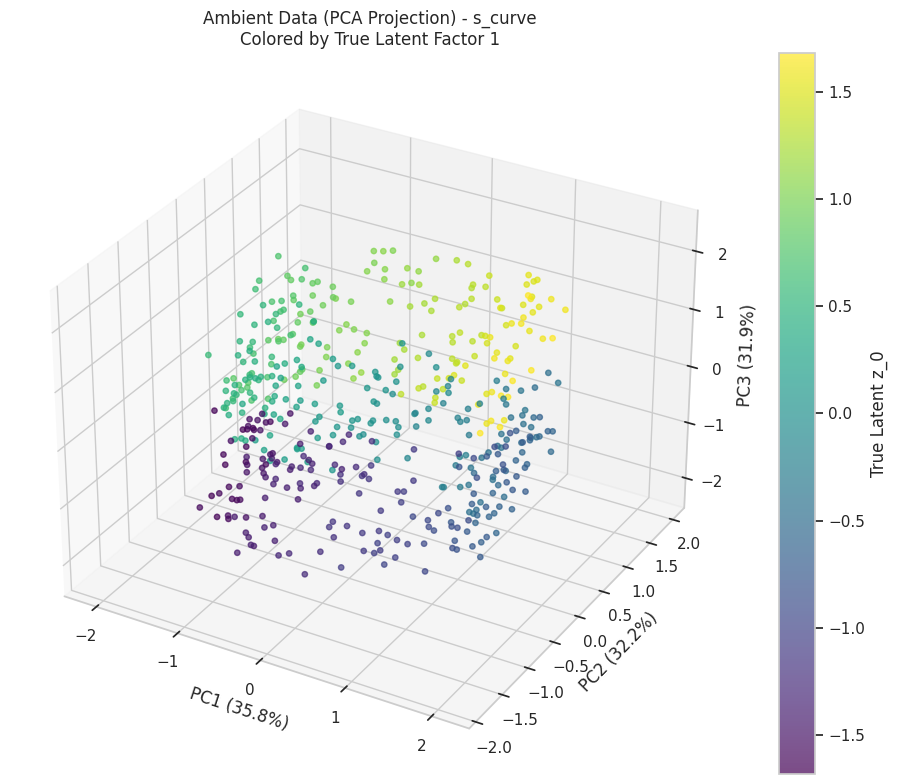


Model Parameter Counts:
  Abstract-AE    : 83,266 parameters
  FB-AE          : 82,367 parameters
  JE-VICReg      : 75,010 parameters
  JEPA           : 100,358 parameters


In [ ]:
print(f"--- Starting Extended Representation Learning Pipeline ---")
print(f"Target Dataset: {config['dataset_name']}")

main_key = jrandom.PRNGKey(config["seed"])
k_data, k_abs, k_fb, k_je, k_jepa, k_train = jrandom.split(main_key, 6)

train_data, val_data, test_data = get_dataloaders(config, k_data)

# Optional: View Ambient Data Structure
visualize_ambient_data(train_data[0], train_data[1], config["dataset_name"])

models = {
    "Abstract-AE": AbstractAE(k_abs, config["n_dim"], config["k_dim"], config["hidden_dim"], config["num_layers"]),
    "FB-AE": FBAE(k_fb, config["n_dim"], config["k_dim"], config["hidden_dim"], config["num_layers"]),
    "JE-VICReg": JEVICReg(k_je, config["n_dim"], config["k_dim"], config["hidden_dim"], config["num_layers"]),
    "JEPA": JEPA(k_jepa, config["n_dim"], config["k_dim"], config["hidden_dim"], config["num_layers"])
}

## Print model parameter counts for sanity check
print("\nModel Parameter Counts:")
for name, model in models.items():
    num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size if isinstance(x, jnp.ndarray) else 0, model)))
    print(f"  {name:15s}: {num_params:,} parameters")

loss_fns = {
    "Abstract-AE": ae_loss_fn, "FB-AE": ae_loss_fn,
    "JE-VICReg": vicreg_loss_fn, "JEPA": jepa_loss_fn
}

In [ ]:
final_models = {}
training_metrics = {}

for name in models.keys():
    trained_model, t_loss, v_loss = train_and_evaluate(name, models[name], loss_fns[name], train_data, val_data, k_train)
    final_models[name] = trained_model
    training_metrics[name] = {"train_losses": t_loss, "val_losses": v_loss}


Training Abstract-AE for 1000 epochs...
  Epoch 0000 | Train Loss: 0.0495 | Val Loss: 0.0477
  Epoch 0100 | Train Loss: 0.0034 | Val Loss: 0.0047
  Epoch 0200 | Train Loss: 0.0016 | Val Loss: 0.0034
  Epoch 0300 | Train Loss: 0.0011 | Val Loss: 0.0029
  Epoch 0400 | Train Loss: 0.0007 | Val Loss: 0.0029
  Epoch 0500 | Train Loss: 0.0006 | Val Loss: 0.0028
  Epoch 0600 | Train Loss: 0.0005 | Val Loss: 0.0027
  Epoch 0700 | Train Loss: 0.0004 | Val Loss: 0.0026
  Epoch 0800 | Train Loss: 0.0004 | Val Loss: 0.0026
  Epoch 0900 | Train Loss: 0.0003 | Val Loss: 0.0025
  Epoch 0999 | Train Loss: 0.0003 | Val Loss: 0.0025

Training FB-AE for 1000 epochs...
  Epoch 0000 | Train Loss: 0.1439 | Val Loss: 0.1221
  Epoch 0100 | Train Loss: 0.0027 | Val Loss: 0.0034
  Epoch 0200 | Train Loss: 0.0020 | Val Loss: 0.0029
  Epoch 0300 | Train Loss: 0.0015 | Val Loss: 0.0028
  Epoch 0400 | Train Loss: 0.0012 | Val Loss: 0.0028
  Epoch 0500 | Train Loss: 0.0011 | Val Loss: 0.0028
  Epoch 0600 | Train Lo

In [ ]:
train_embeddings = {}
test_embeddings = {}
eval_metrics = {}

for name, model in final_models.items():
    # Extract Training Embeddings
    if name in ["Abstract-AE", "FB-AE"]:
        _, z_train = jax.vmap(model)(train_data[0])
        _, z_test = jax.vmap(model)(test_data[0])
    else:
        z_train = jax.vmap(model)(train_data[0])
        z_test = jax.vmap(model)(test_data[0])
        
    train_embeddings[name] = z_train
    test_embeddings[name] = z_test
    
    # Calculate Test Metrics
    eval_metrics[name] = {
        "mcc": calculate_mcc(z_test, test_data[1]),
        "r2": calculate_r2(z_test, test_data[1])
    }

print("\n--- Final Evaluation Summary ---")
for name, res in eval_metrics.items():
    print(f"{name:15s} | MCC: {res['mcc']:.4f} | R²: {res['r2']:.4f}")


--- Final Evaluation Summary ---
Abstract-AE     | MCC: 0.5514 | R²: 0.3441
FB-AE           | MCC: 0.7022 | R²: 0.7969
JE-VICReg       | MCC: 0.3837 | R²: 0.4726
JEPA            | MCC: 0.4462 | R²: 0.3633



Generating Loss Visualization...


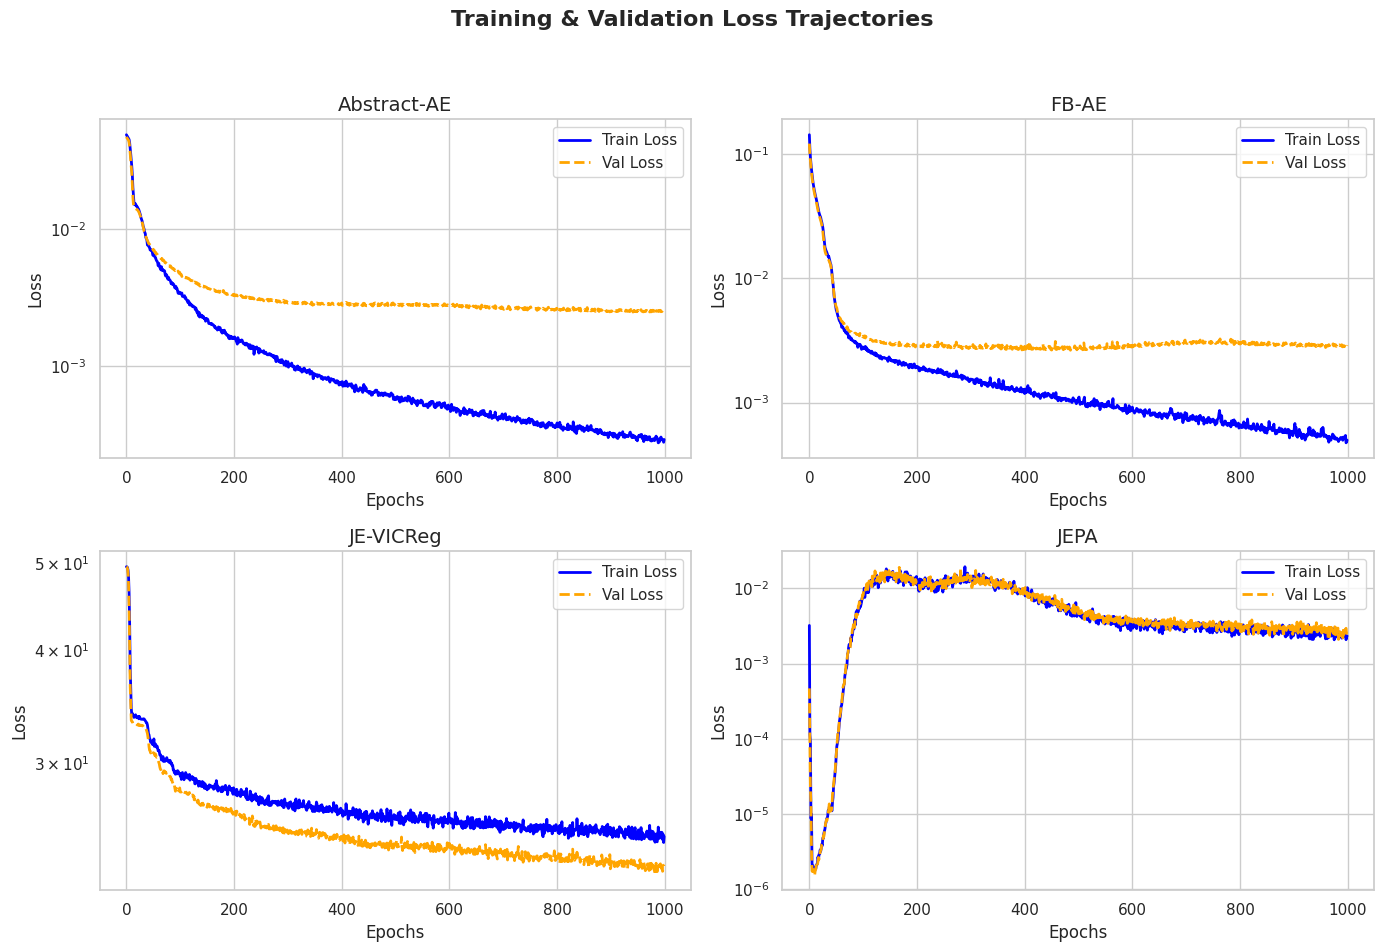

In [ ]:
print("\nGenerating Loss Visualization...")
plot_losses(training_metrics)

Generating Latent Space Geometry Visualization (Training Data)...


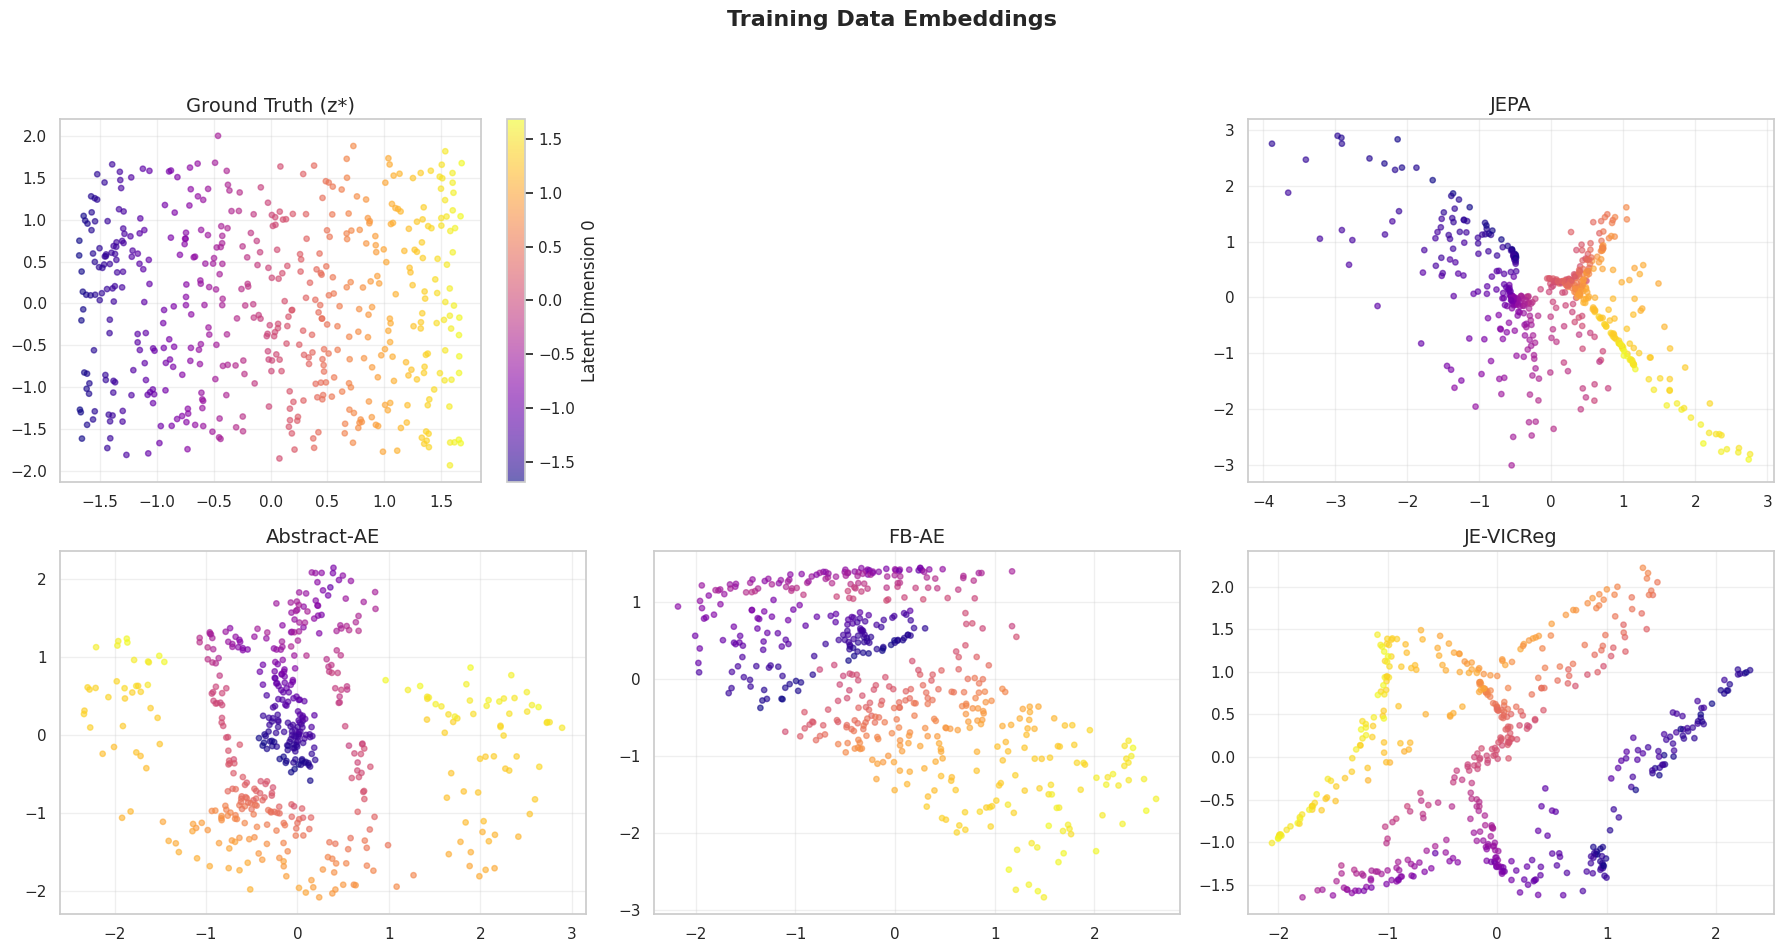

In [ ]:
print("Generating Latent Space Geometry Visualization (Training Data)...")
plot_latent_spaces(train_embeddings, train_data[1], title="Training Data Embeddings")

Generating Latent Space Geometry Visualization (Test Data)...


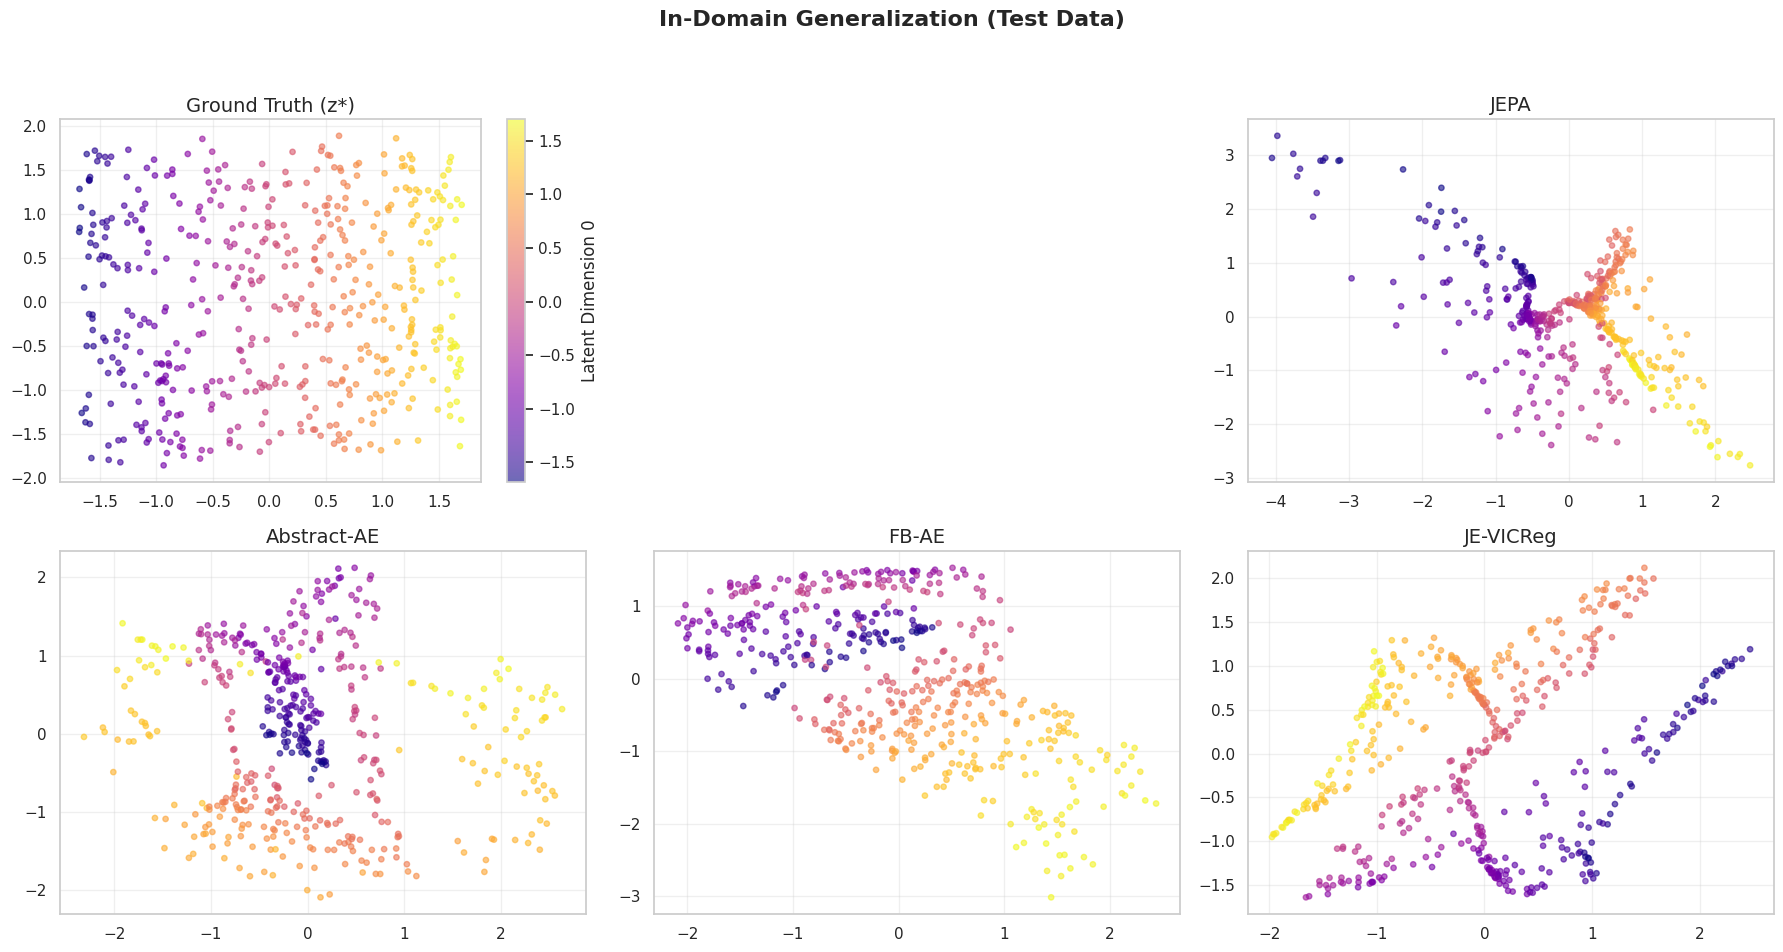

In [ ]:
print("Generating Latent Space Geometry Visualization (Test Data)...")
plot_latent_spaces(test_embeddings, test_data[1], title="In-Domain Generalization (Test Data)")

Generating Metrics Bar Chart...


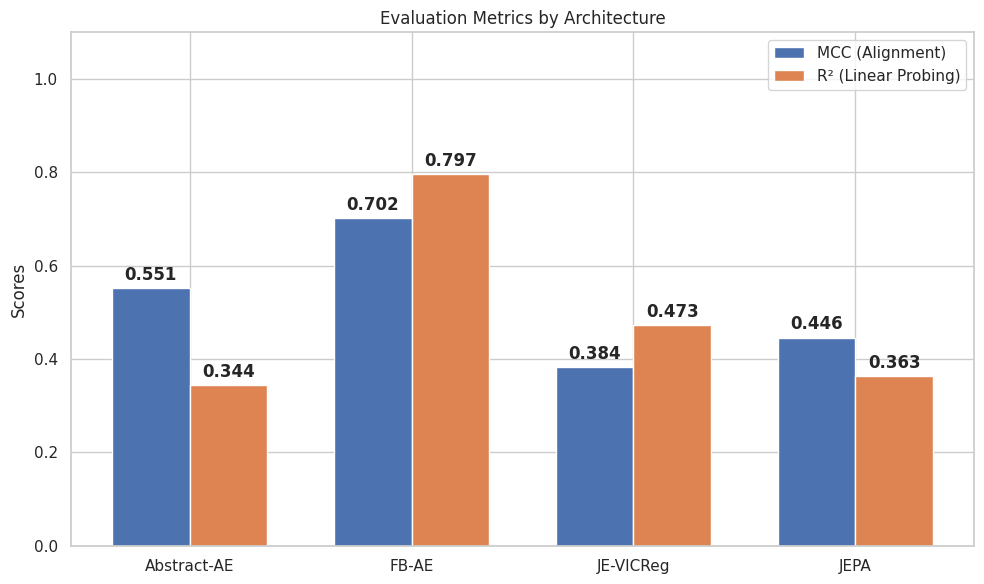

Pipeline Complete.


In [ ]:
print("Generating Metrics Bar Chart...")
plot_metrics_barchart(eval_metrics)

print("Pipeline Complete.")